Paso 1: Configuración del Entorno y Librerías
- Descripción: "Importamos el stack tecnológico necesario para el procesamiento de datos y la generación de gráficos, asegurando que todas las herramientas analíticas estén disponibles."

In [1]:
### Inicialización del Proyecto
# Gestión de dependencias y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para gráficos integrados
%matplotlib inline

Paso 2: Ingesta del Dataset de Ventas
- Descripción: "Realizamos la lectura del archivo fuente de ventas. Accedemos al set de datos original mediante el método de lectura de CSV, asignándolo a un DataFrame para iniciar el proceso de transformación."

In [2]:
# Importación de los datos crudos desde el directorio de trabajo
df_ventas_base = pd.read_csv("../data/SalesFINAL12312016.csv", delimiter=',')

Paso 3: Inspección Visual de los Datos
- Descripción: "Para obtener una visión preliminar del conjunto de información cargado, visualizamos los registros iniciales del DataFrame. Esto nos permite validar que los encabezados y los valores se han importado según lo esperado."

In [3]:
# Visualización de la parte superior del conjunto de datos
df_ventas_base.head(5)

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


Paso 4: Función de Auditoría de Metadatos
- Descripción: "Desarrollamos una utilidad personalizada para centralizar el diagnóstico del DataFrame. Esta función genera un resumen ejecutivo que incluye tipos de datos, conteo de valores únicos y el impacto de los registros faltantes en cada variable."

In [4]:
# Definición de herramienta para el diagnóstico de calidad de datos
def auditoria_dataset(dataframe):
    # Inicializamos una lista para recolectar las métricas de cada columna
    resumen_metricas = []
    
    for item in dataframe.columns:
        # Extracción de métricas individuales por variable
        clase_dato = dataframe[item].dtype
        total_registros = len(dataframe[item])
        conteo_unicos = dataframe[item].nunique()
        nulos_detectados = dataframe[item].isnull().sum()
        ratio_nulos = (nulos_detectados / total_registros) * 100
        
        # Consolidación de los hallazgos en la lista
        resumen_metricas.append({
            'Variable': item,
            'Dtype': clase_dato,
            'Registros': total_registros,
            'Unicidad': conteo_unicos,
            'Nulos': nulos_detectados,
            'Nulos (%)': round(ratio_nulos, 4)
        })
    
    # Retornamos el reporte como un nuevo objeto DataFrame
    return pd.DataFrame(resumen_metricas)

# Ejecución del reporte sobre el conjunto de ventas
auditoria_dataset(df_ventas_base)

,Variable,Dtype,Registros,Unicidad,Nulos,Nulos (%)
0,InventoryId,str,1048575,170131,0,0.0
1,Store,int64,1048575,79,0,0.0
2,Brand,int64,1048575,7658,0,0.0
3,Description,str,1048575,6890,0,0.0
4,Size,str,1048575,40,0,0.0
5,SalesQuantity,int64,1048575,141,0,0.0
6,SalesDollars,float64,1048575,3426,0,0.0
7,SalesPrice,float64,1048575,273,0,0.0
8,SalesDate,str,1048575,60,0,0.0
9,Volume,int64,1048575,22,0,0.0


Paso 5: Verificación de Integridad (Duplicados)
- Descripción: "Evaluamos la existencia de registros idénticos dentro del set de datos. Este control es preventivo y nos permite determinar si el volumen de ventas está inflado por redundancias técnicas antes de proceder con el preprocesamiento."

In [5]:
# Comprobación de filas redundantes en el historial
hay_redundancias = df_ventas_base.duplicated().any()

# Salida de control basada en el resultado booleano
if hay_redundancias:
    print("Estado del dataset: Se han detectado registros duplicados.")
else:
    print("Estado del dataset: Integridad confirmada (sin duplicados).")

Estado del dataset: Integridad confirmada (sin duplicados).


Paso 6: Análisis Estadístico Univariado
- Descripción: "Ejecutamos una exploración descriptiva detallada mediante una iteración por cada variable del set de datos. Este proceso nos permite observar tendencias, promedios y posibles anomalías estadísticas en cada columna de forma independiente."

In [6]:
# Inspección individual de métricas por columna
for variable in df_ventas_base.columns:
    print(f"Campo: {variable}")
    print(df_ventas_base[variable].describe())
    print('------------------------------------')

Campo: InventoryId
count                1048575
unique                170131
top       13_TARMSWORTH_8064
freq                      57
Name: InventoryId, dtype: object
------------------------------------
Campo: Store
count    1.048575e+06
mean     4.008063e+01
std      2.435739e+01
min      1.000000e+00
25%      1.500000e+01
50%      3.900000e+01
75%      6.400000e+01
max      7.900000e+01
Name: Store, dtype: float64
------------------------------------
Campo: Brand
count    1.048575e+06
mean     1.216959e+04
std      1.241921e+04
min      5.800000e+01
25%      3.680000e+03
50%      6.296000e+03
75%      1.795400e+04
max      9.008900e+04
Name: Brand, dtype: float64
------------------------------------
Campo: Description
count               1048575
unique                 6890
top       Smirnoff 80 Proof
freq                   7123
Name: Description, dtype: object
------------------------------------
Campo: Size
count     1048575
unique         40
top         750mL
freq       593098
Na

Paso 7: ETL - Normalización de Nomenclatura
- Descripción: "Iniciamos la fase de transformación de datos traduciendo y estandarizando los encabezados de las columnas. Aplicamos el método de renombrado para asegurar que los nombres sean intuitivos y profesionales, facilitando la interpretación del negocio."

In [7]:
# Definición del diccionario de mapeo para el cambio de nombres
mapeo_columnas = {
    'InventoryId': 'Inventario_ID',
    'Store': 'Tienda',
    'Brand': 'Marca_ID',
    'Description': 'Descripcion',
    'Size': 'Tamaño',
    'SalesQuantity': 'Cantidad_Ventas',
    'SalesDollars': 'Venta_Total',
    'SalesPrice': 'Precio_Unitario',
    'SalesDate': 'Fecha_Venta',
    'Volume': 'Volumen',
    'Classification': 'Clasificacion',
    'ExciseTax': 'Impuesto',
    'VendorNo': 'Proveedor_ID',
    'VendorName': 'Nombre_Proveedor'
}

# Ejecución del renombrado de forma persistente
df_ventas_base.rename(columns=mapeo_columnas, inplace=True)

Paso 8: Generación de Identificadores Únicos
- Descripción: "Implementamos claves primarias artificiales para cada registro. Mediante una secuencia numérica correlativa, asignamos identificadores únicos tanto para la gestión de inventario como para el registro individual de transacciones, asegurando la trazabilidad de cada fila."

In [8]:
# Creación de índices incrementales para llaves primarias
total_filas = df_ventas_base.shape[0]

# Generamos las secuencias usando arreglos de numpy para mayor eficiencia
df_ventas_base['Inventario_Inicial_ID'] = np.arange(1, total_filas + 1)
df_ventas_base['Ventas_ID'] = np.arange(1, total_filas + 1)

# Verificación de la estructura con los nuevos identificadores
print(df_ventas_base.head())

         Inventario_ID  Tienda  Marca_ID                 Descripcion  \
0  1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
1  1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
2  1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
3  1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
4  1_HARDERSFIELD_1005       1      1005     Maker's Mark Combo Pack   

       Tamaño  Cantidad_Ventas  Venta_Total  Precio_Unitario Fecha_Venta  \
0       750mL                1        16.49            16.49    1/1/2016   
1       750mL                2        32.98            16.49    1/2/2016   
2       750mL                1        16.49            16.49    1/3/2016   
3       750mL                1        14.49            14.49    1/8/2016   
4  375mL 2 Pk                2        69.98            34.99    1/9/2016   

   Volumen  Clasificacion  Impuesto  Proveedor_ID  \
0      750              1      0.79         12546   
1   

Paso 9: Normalización de Unidades Físicas (Cómputo de Packs)
- Descripción: "Tratamos las irregularidades en la descripción de formatos. Extraemos el multiplicador de los productos vendidos en paquetes (ej. '6 Pk') para contabilizar correctamente la cantidad de unidades físicas reales, estandarizando el volumen de salida."

In [9]:
import re

# Definición de lógica para detección de empaques múltiples
def calcular_unidades_fisicas(valor_medida):
    # Convertimos a string y buscamos el patrón numérico asociado a 'Pk'
    texto = str(valor_medida)
    if 'Pk' in texto:
        # Buscamos dígitos que preceden a la palabra clave 'Pk'
        resultado = re.findall(r'(\d+)\s*Pk', texto)
        return int(resultado[0]) if resultado else 1
    return 1

# Creación de la columna 'Cantidad' basada en el análisis de la medida
df_ventas_base['Cantidad'] = df_ventas_base['Tamaño'].map(calcular_unidades_fisicas)

# Inspección de los resultados procesados
print(df_ventas_base)

               Inventario_ID  Tienda  Marca_ID                 Descripcion  \
0        1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
1        1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
2        1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
3        1_HARDERSFIELD_1004       1      1004  Jim Beam w/2 Rocks Glasses   
4        1_HARDERSFIELD_1005       1      1005     Maker's Mark Combo Pack   
...                      ...     ...       ...                         ...   
1048570  19_WINTERVALE_39384      19     39384    F Coppola Diamond Pnt Nr   
1048571  19_WINTERVALE_39384      19     39384    F Coppola Diamond Pnt Nr   
1048572  19_WINTERVALE_39384      19     39384    F Coppola Diamond Pnt Nr   
1048573  19_WINTERVALE_39384      19     39384    F Coppola Diamond Pnt Nr   
1048574  19_WINTERVALE_39384      19     39384    F Coppola Diamond Pnt Nr   

             Tamaño  Cantidad_Ventas  Venta_Total  Precio_Unita

Paso 10: Persistencia del Dataset Procesado
- Descripción: "Exportamos la información depurada a un archivo físico. Almacenamos el DataFrame resultante en formato CSV dentro de la carpeta de datos procesados para su posterior consumo en herramientas de BI o bases de datos SQL."

In [10]:
# Definimos el destino y guardamos los datos sin el índice de pandas
ruta_final = "../data/DatosProcesados/Ventas_Limpias_Final.csv"
df_ventas_base.to_csv(ruta_final, index=False)

Paso de Carga del Dataset Limpio
- Descripción: "Recuperamos el set de datos procesado desde el almacenamiento local. Este paso garantiza la persistencia de las transformaciones anteriores y nos permite trabajar con la versión final y depurada de la información para los análisis visuales."

In [11]:
# Establecemos la ruta del archivo generado anteriormente
path_datos_limpios = "../data/DatosProcesados/Ventas_Limpias_Final.csv"

# Importamos el dataframe usando un motor de lectura alternativo
df_analisis = pd.read_table(path_datos_limpios, sep=',')

# Verificamos que la carga sea íntegra
print(f"Dataset listo para visualización. Total de registros: {len(df_analisis)}")

Dataset listo para visualización. Total de registros: 1048575


Paso 11: Análisis de Tendencia Temporal (Ingresos)
- Descripción: "Evaluamos el flujo de ingresos a lo largo del tiempo. Seteamos el formato cronológico y consolidamos la facturación diaria para identificar patrones estacionales o picos de demanda en la serie histórica."

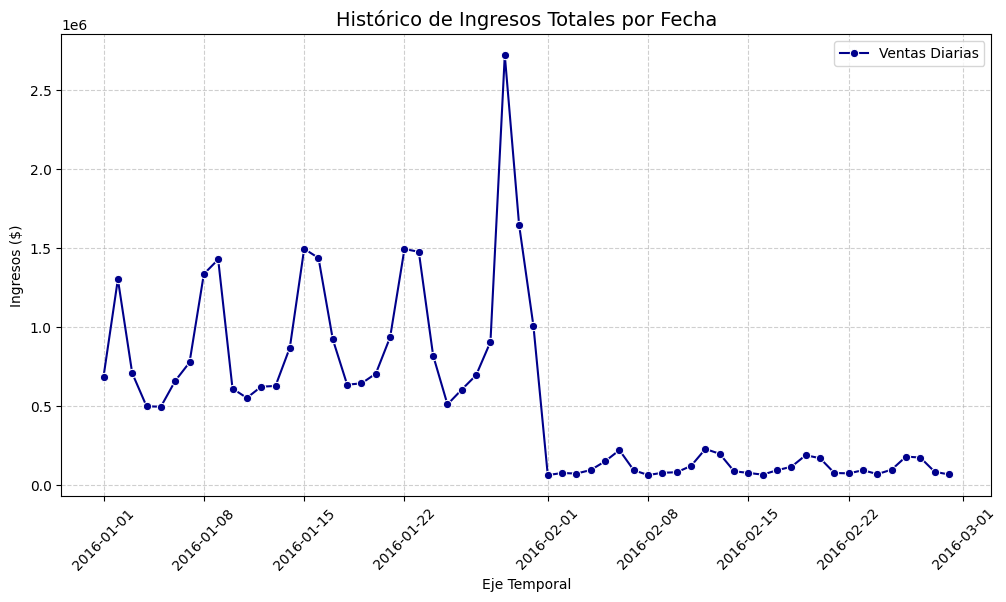

In [12]:
# Aseguramos el tipo de dato temporal
df_analisis['Fecha_Venta'] = pd.to_datetime(df_analisis['Fecha_Venta'])

# Agregamos los ingresos por día usando una técnica de agrupación directa
cronologia_ventas = df_analisis.groupby('Fecha_Venta')['Venta_Total'].sum().reset_index()

# Generación de la gráfica de evolución
plt.figure(figsize=(12, 6))
sns.lineplot(data=cronologia_ventas, x='Fecha_Venta', y='Venta_Total', 
             color='darkblue', marker='o', label='Ventas Diarias')

plt.title('Histórico de Ingresos Totales por Fecha', fontsize=14)
plt.xlabel('Eje Temporal')
plt.ylabel('Ingresos ($)')
plt.xticks(rotation=45)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Paso 12: Identificación de Proveedores con Mayor Volumen
- Descripción: "Segmentamos a los proveedores según su volumen de salida de unidades. Filtramos a los socios estratégicos que superan las 10,000 unidades vendidas para visualizar a los actores más relevantes de la cadena de suministro."

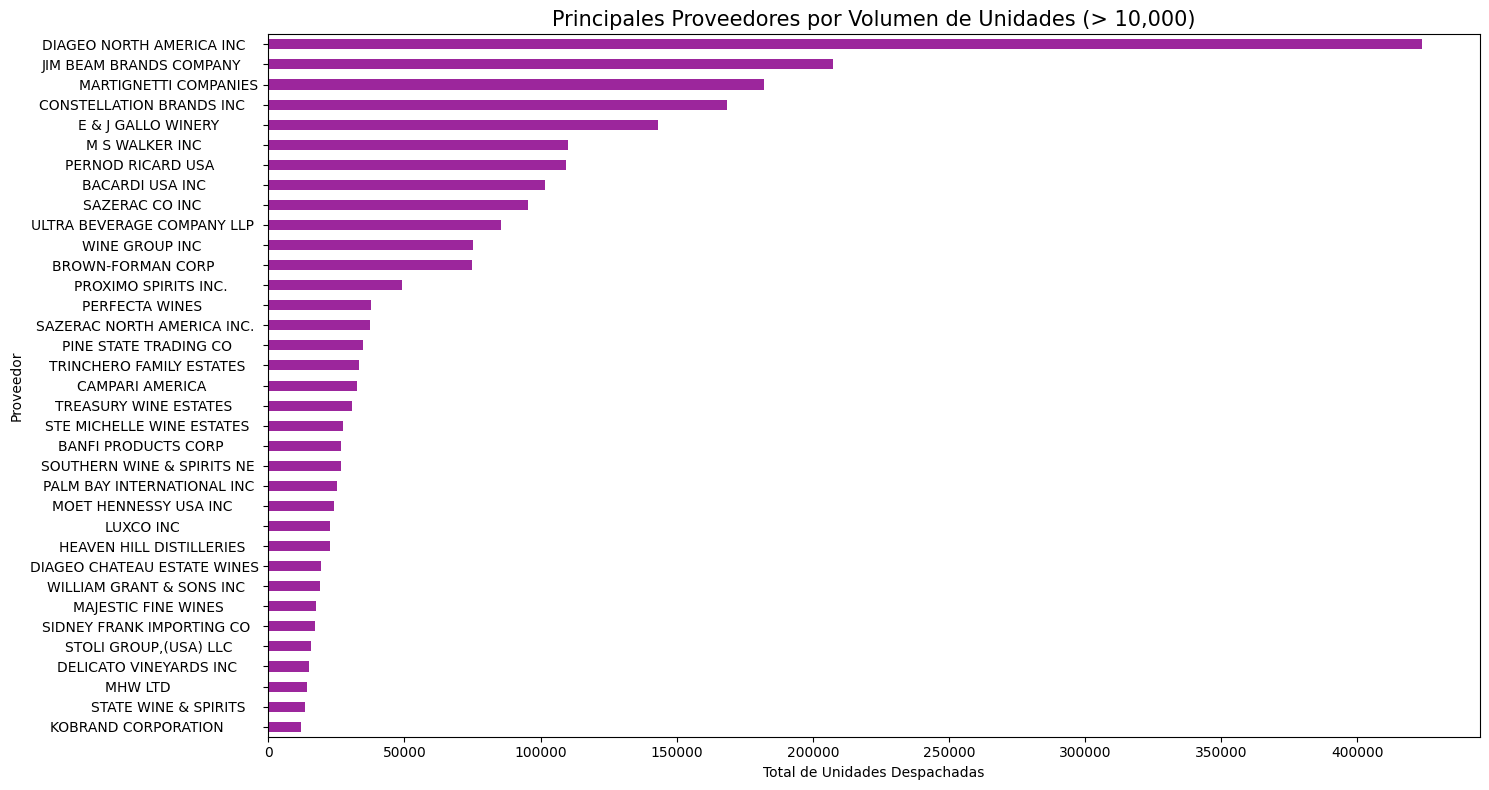

In [13]:
# Calculamos el volumen total por razón social
metricas_proveedor = df_analisis.groupby('Nombre_Proveedor')['Cantidad_Ventas'].sum()

# Seleccionamos únicamente a los proveedores de alto impacto (> 10k)
top_proveedores = metricas_proveedor[metricas_proveedor > 10000].sort_values(ascending=True)

# Visualización del desempeño mediante barras horizontales
plt.figure(figsize=(15, 8))
top_proveedores.plot(kind='barh', color='darkmagenta', alpha=0.85)

plt.title('Principales Proveedores por Volumen de Unidades (> 10,000)', fontsize=15)
plt.xlabel('Total de Unidades Despachadas')
plt.ylabel('Proveedor')
plt.tight_layout()
plt.show()

Paso 22: Transformación a Modelo Dimensional (Split de Tablas)
- Descripción: "Segmentamos el dataset de ventas procesado para separar las métricas transaccionales de las dimensiones descriptivas. En este paso, vinculamos cada venta con su correspondiente ID de producto, tienda y fecha, asegurando la integridad del modelo estrella."

In [22]:
# --- GENERACIÓN DE DIMENSIONES Y LLAVES ---

# 1. Dim_Calendario: Generamos la llave temporal AAAAMMDD
# Usamos 'Fecha_Venta' (columna normalizada en el Paso 8 del notebook)
df_ventas_base['Fecha_ID'] = pd.to_datetime(df_ventas_base['Fecha_Venta']).dt.strftime('%Y%m%d').astype(int)

Paso 23: Construcción de la Tabla de Hechos (Fact_Ventas)
- Descripción: "Estructuramos la tabla de hechos de ventas consolidando las métricas de cantidad y precio junto a sus llaves foráneas. Esta tabla representa el núcleo transaccional del DWH, optimizada para el análisis de ingresos y rotación de inventario en Power BI."

In [23]:
# Selección de columnas según la limpieza realizada y el diagrama corregido
# Usamos 'Ventas_ID' que es el nombre real en el DataFrame
fact_ventas = df_ventas_base[[
    'Ventas_ID',        # Se renombrará a Venta_ID (PK)
    'Marca_ID',         # FK a Dim_Producto
    'Tienda',           # Se renombrará a Tienda_ID (FK)
    'Fecha_ID',         # FK a Dim_Calendario
    'Cantidad_Ventas',  # Se renombrará a Cantidad
    'Venta_Total',      # Métrica (coincide con diagrama)
    'Precio_Unitario',  # Métrica (coincide con diagrama)
    'Impuesto'          # Métrica (coincide con diagrama)
]].copy()

# Renombrado para coincidencia exacta con el diagrama estrella final
fact_ventas.rename(columns={
    'Ventas_ID': 'Venta_ID',
    'Tienda': 'Tienda_ID',
    'Cantidad_Ventas': 'Cantidad'
}, inplace=True)

Paso 24: Exportación Final a la Carpeta de Ingesta
- Descripción: "Persistimos la tabla de hechos de ventas en la carpeta '../data/DatosIngesta/'. Con este archivo, completamos el set de datos necesario para la construcción física de la base de datos SQL Server."

In [24]:
# Definición de la ruta de ingesta organizada
ruta_ingesta = "../data/DatosIngesta/"

# Exportación definitiva
fact_ventas.to_csv(ruta_ingesta + "Fact_Ventas.csv", index=False)

print(f"--- PROCESO DE INGESTA COMPLETADO ---")
print(f"Archivo generado exitosamente en: {ruta_ingesta}Fact_Ventas.csv")

--- PROCESO DE INGESTA COMPLETADO ---
Archivo generado exitosamente en: ../data/DatosIngesta/Fact_Ventas.csv
